<a href="https://colab.research.google.com/github/CaptainRushi/fly_connectome_gnn9/blob/main/fly_connectome_gnn1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fruit Fly Connectome — Graph Neural Network

Real biological wiring diagram (FlyWire FAFB, ~139k neurons, ~130M synapses) as graph-ML data. Task: **node classification** — predict a neuron's cell-class from its connectivity pattern alone (no morphology, no manual features).

Data source: https://codex.flywire.ai (FlyWire Consortium, Princeton).

## 1. Install deps (PyTorch Geometric matched to Colab's torch/CUDA)

In [1]:
import torch
print('torch', torch.__version__, '| cuda', torch.version.cuda)

# base pyg only — skip pyg_lib/scatter/sparse/cluster extras, they compile slow.
# SAGEConv below don't need them. add back later only if a later cell errors asking for one.
!pip install -q torch_geometric

import torch_geometric
print('PyG', torch_geometric.__version__, 'installed OK')

torch 2.11.0+cu128 | cuda 12.8
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.7 MB/s eta 0:00:00
PyG 2.8.0.post1 installed OK


## 2. Download FlyWire connectome data

Pulls directly from the public GCS bucket Codex serves from — no login needed.
Grabs connections (edges), classification (labels), and coordinates (x,y,z soma
position — used later for the 3D render). The `file data/*.gz` check confirms
real gzip (not an HTML error page). If it ever breaks, browse
https://codex.flywire.ai/app -> Download Data to get a fresh link.

In [2]:
import os
os.makedirs('data', exist_ok=True)

# Direct GCS bucket for FlyWire FAFB v783 (Codex export mirror) —
# confirmed working path, no login/API-key needed.
BASE = 'https://storage.googleapis.com/flywire-data/codex/data/fafb/783'

!wget -q -O data/connections.csv.gz "$BASE/connections.csv.gz" && echo 'connections OK'
!wget -q -O data/classification.csv.gz "$BASE/classification.csv.gz" && echo 'classification OK'
!wget -q -O data/coordinates.csv.gz "$BASE/coordinates.csv.gz" && echo 'coordinates OK'

!ls -la data/
!file data/connections.csv.gz data/classification.csv.gz data/coordinates.csv.gz

connections OK
classification OK
coordinates OK
total 55228
drwxr-xr-x 2 root root     4096 Sep 17 10:42 .
drwxr-xr-x 1 root root     4096 Sep 17 10:42 ..
-rw-r--r-- 1 root root   934402 Feb 24  2026 classification.csv.gz
-rw-r--r-- 1 root root 50289304 Dec  5  2024 connections.csv.gz
-rw-r--r-- 1 root root  5314546 Dec  5  2024 coordinates.csv.gz
data/connections.csv.gz:    gzip compressed data, was "connections.csv", last modified: Mon Feb 26 14:22:36 2024, max compression, original size modulo 2^32 198264132
data/classification.csv.gz: gzip compressed data, was "classification.csv", last modified: Tue Feb 24 13:54:07 2026, max compression, original size modulo 2^32 9989744
data/coordinates.csv.gz:    gzip compressed data, was "coordinates.csv", last modified: Tue Dec 26 13:44:40 2023, max compression, original size modulo 2^32 14573481


## 3. Load + inspect

Expected columns (Codex FAFB export):
- `connections`: `pre_root_id`, `post_root_id`, `syn_count`, `nt_type`
- `classification`: `root_id`, `super_class` (this is our prediction target), `class`, `cell_type`

If Codex renamed a column, the print below shows you the real names — adjust
`SRC_COL` / `DST_COL` / `LABEL_COL` in the next cell accordingly.

In [3]:
import pandas as pd

conn = pd.read_csv('data/connections.csv.gz', compression='gzip')
cls = pd.read_csv('data/classification.csv.gz', compression='gzip')

print('connections:', conn.shape, list(conn.columns))
print('classification:', cls.shape, list(cls.columns))
cls.head()

connections: (3869878, 5) ['pre_root_id', 'post_root_id', 'neuropil', 'syn_count', 'nt_type']
classification: (139255, 8) ['root_id', 'flow', 'super_class', 'class', 'sub_class', 'hemilineage', 'side', 'nerve']


,root_id,flow,super_class,class,sub_class,hemilineage,side,nerve
0,720575940599457990,intrinsic,optic,optic_lobe_intrinsic,t4_neuron,NaN,right,NaN
1,720575940599763910,intrinsic,optic,optic_lobe_intrinsic,t5_neuron,NaN,right,NaN
2,720575940600623020,intrinsic,optic,optic_lobe_intrinsic,distal_medulla,NaN,right,NaN
3,720575940602309600,afferent,sensory_ascending,AN,SA_DMT_DMetaN,NaN,right,CV
4,720575940602564320,intrinsic,central,Kenyon_Cell,KCg,MBp4,right,NaN


## 4. Build the graph

In [4]:
import torch
import numpy as np
from torch_geometric.data import Data

SRC_COL, DST_COL, WEIGHT_COL = 'pre_root_id', 'post_root_id', 'syn_count'
ID_COL, LABEL_COL = 'root_id', 'super_class'

cls = cls.dropna(subset=[LABEL_COL]).reset_index(drop=True)

node_ids = cls[ID_COL].unique()
id_to_idx = {nid: i for i, nid in enumerate(node_ids)}
n_nodes = len(node_ids)
print('nodes with labels:', n_nodes)

conn = conn[conn[SRC_COL].isin(id_to_idx) & conn[DST_COL].isin(id_to_idx)]
src = conn[SRC_COL].map(id_to_idx).values
dst = conn[DST_COL].map(id_to_idx).values
weight = conn[WEIGHT_COL].values.astype(np.float32) if WEIGHT_COL in conn.columns else np.ones(len(src), dtype=np.float32)
print('edges after filtering to labeled nodes:', len(src))

edge_index = torch.tensor(np.vstack([src, dst]), dtype=torch.long)
edge_weight = torch.tensor(weight, dtype=torch.float)

labels_sorted = sorted(cls[LABEL_COL].unique())
label_to_idx = {l: i for i, l in enumerate(labels_sorted)}
y = torch.zeros(n_nodes, dtype=torch.long)
for _, row in cls.iterrows():
    y[id_to_idx[row[ID_COL]]] = label_to_idx[row[LABEL_COL]]

print('classes:', labels_sorted)
print('class distribution:', torch.bincount(y).tolist())

nodes with labels: 139255
edges after filtering to labeled nodes: 3869878
classes: ['ascending', 'central', 'descending', 'endocrine', 'motor', 'optic', 'sensory', 'sensory_ascending', 'visual_centrifugal', 'visual_projection']
class distribution: [1750, 32381, 1305, 80, 110, 77873, 16938, 612, 522, 7684]


## 5. Node features

No morphology data used — features are purely structural (in/out degree,
weighted in/out strength, clustering coefficient). This is the honest
version: the model has to learn class from **wiring pattern alone**.

In [5]:
from torch_geometric.utils import degree

in_deg = degree(edge_index[1], num_nodes=n_nodes)
out_deg = degree(edge_index[0], num_nodes=n_nodes)

in_strength = torch.zeros(n_nodes)
out_strength = torch.zeros(n_nodes)
in_strength.scatter_add_(0, edge_index[1], edge_weight)
out_strength.scatter_add_(0, edge_index[0], edge_weight)

x = torch.stack([
    in_deg, out_deg, in_strength, out_strength,
    torch.log1p(in_deg), torch.log1p(out_deg),
], dim=1)
x = (x - x.mean(0)) / (x.std(0) + 1e-6)

print('feature matrix:', x.shape)

feature matrix: torch.Size([139255, 6])


## 6. Train / val / test split + PyG Data object

In [6]:
from sklearn.model_selection import train_test_split

idx = np.arange(n_nodes)
train_idx, temp_idx = train_test_split(idx, test_size=0.3, stratify=y.numpy(), random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=y.numpy()[temp_idx], random_state=42)

train_mask = torch.zeros(n_nodes, dtype=torch.bool); train_mask[train_idx] = True
val_mask = torch.zeros(n_nodes, dtype=torch.bool); val_mask[val_idx] = True
test_mask = torch.zeros(n_nodes, dtype=torch.bool); test_mask[test_idx] = True

data = Data(x=x, edge_index=edge_index, edge_attr=edge_weight.unsqueeze(1), y=y,
            train_mask=train_mask, val_mask=val_mask, test_mask=test_mask)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)
print(data)
print('device:', device)

Data(x=[139255, 6], edge_index=[2, 3869878], edge_attr=[3869878, 1], y=[139255], train_mask=[139255], val_mask=[139255], test_mask=[139255])
device: cuda


## 7. GNN model (GraphSAGE — scales better than plain GCN on 100M+ edges)

In [7]:
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class FlyGNN(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, n_classes, dropout=0.3):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        self.conv3 = SAGEConv(hidden_dim, n_classes)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv3(x, edge_index)

n_classes = len(labels_sorted)
model = FlyGNN(in_dim=x.shape[1], hidden_dim=128, n_classes=n_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
print(model)

FlyGNN(
  (conv1): SAGEConv(6, 128, aggr=mean)
  (conv2): SAGEConv(128, 128, aggr=mean)
  (conv3): SAGEConv(128, 10, aggr=mean)
)


## 8. Train

Full-batch (fits on a T4 for ~139k nodes). If you hit OOM, switch to
`NeighborLoader` mini-batching — flag it and ask, don't just crank down data size silently.

In [8]:
def accuracy(logits, y, mask):
    pred = logits[mask].argmax(dim=1)
    return (pred == y[mask]).float().mean().item()

history = {'train_loss': [], 'val_acc': []}
best_val = 0.0

for epoch in range(1, 201):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            out = model(data.x, data.edge_index)
            val_acc = accuracy(out, data.y, data.val_mask)
        history['train_loss'].append(loss.item())
        history['val_acc'].append(val_acc)
        if val_acc > best_val:
            best_val = val_acc
            torch.save(model.state_dict(), 'best_model.pt')
        print(f'epoch {epoch:3d} | loss {loss.item():.4f} | val_acc {val_acc:.4f}')

print('best val acc:', best_val)

epoch   1 | loss 2.4196 | val_acc 0.5835
epoch  10 | loss 0.9654 | val_acc 0.7843
epoch  20 | loss 0.7096 | val_acc 0.8173
epoch  30 | loss 0.5951 | val_acc 0.8387
epoch  40 | loss 0.5272 | val_acc 0.8547
epoch  50 | loss 0.5001 | val_acc 0.8548
epoch  60 | loss 0.4508 | val_acc 0.8664
epoch  70 | loss 0.4213 | val_acc 0.8788
epoch  80 | loss 0.3885 | val_acc 0.8845
epoch  90 | loss 0.3718 | val_acc 0.8886
epoch 100 | loss 0.3580 | val_acc 0.8923
epoch 110 | loss 0.3473 | val_acc 0.8972
epoch 120 | loss 0.3302 | val_acc 0.9009
epoch 130 | loss 0.3207 | val_acc 0.9051
epoch 140 | loss 0.3127 | val_acc 0.9075
epoch 150 | loss 0.3061 | val_acc 0.9077
epoch 160 | loss 0.2994 | val_acc 0.9102
epoch 170 | loss 0.3008 | val_acc 0.9131
epoch 180 | loss 0.2975 | val_acc 0.9144
epoch 190 | loss 0.2917 | val_acc 0.9147
epoch 200 | loss 0.2876 | val_acc 0.9159
best val acc: 0.9158847332000732


## 9. Test evaluation + per-class report

In [9]:
from sklearn.metrics import classification_report, confusion_matrix

model.load_state_dict(torch.load('best_model.pt'))
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)
    test_acc = accuracy(out, data.y, data.test_mask)
    preds = out[data.test_mask].argmax(dim=1).cpu().numpy()
    true = data.y[data.test_mask].cpu().numpy()

print('test accuracy:', test_acc)
print(classification_report(true, preds, target_names=labels_sorted, zero_division=0))

test accuracy: 0.9153143167495728
                    precision    recall  f1-score   support

         ascending       0.67      0.40      0.50       263
           central       0.91      0.97      0.94      4857
        descending       0.83      0.26      0.39       196
         endocrine       0.00      0.00      0.00        12
             motor       1.00      0.56      0.72        16
             optic       0.95      0.97      0.96     11681
           sensory       0.84      0.94      0.89      2541
 sensory_ascending       0.40      0.04      0.08        92
visual_centrifugal       0.80      0.05      0.10        78
 visual_projection       0.78      0.47      0.58      1153

          accuracy                           0.92     20889
         macro avg       0.72      0.47      0.52     20889
      weighted avg       0.91      0.92      0.91     20889



## 10. Plot training curve

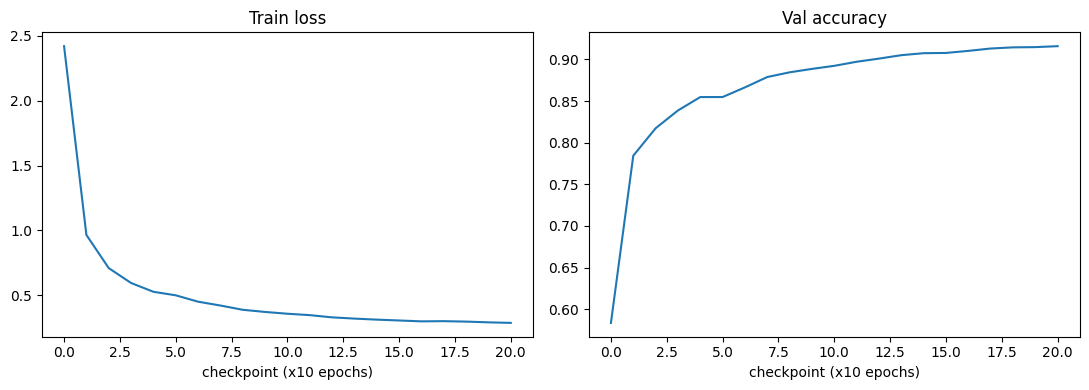

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history['train_loss']); ax[0].set_title('Train loss'); ax[0].set_xlabel('checkpoint (x10 epochs)')
ax[1].plot(history['val_acc']); ax[1].set_title('Val accuracy'); ax[1].set_xlabel('checkpoint (x10 epochs)')
plt.tight_layout(); plt.show()

## 11. Save artifacts for portfolio / resume writeup

Downloads a results JSON — put the numbers straight into a README or
resume bullet, don't round up.

In [11]:
import json
from google.colab import files

results = {
    'dataset': 'FlyWire FAFB connectome',
    'n_nodes': n_nodes,
    'n_edges': int(edge_index.shape[1]),
    'n_classes': n_classes,
    'model': 'GraphSAGE (3-layer)',
    'features': 'structural only (degree + strength), no morphology',
    'test_accuracy': test_acc,
    'best_val_accuracy': best_val,
}
with open('results.json', 'w') as f:
    json.dump(results, f, indent=2)
print(json.dumps(results, indent=2))

files.download('results.json')
files.download('best_model.pt')

{
  "dataset": "FlyWire FAFB connectome",
  "n_nodes": 139255,
  "n_edges": 3869878,
  "n_classes": 10,
  "model": "GraphSAGE (3-layer)",
  "features": "structural only (degree + strength), no morphology",
  "test_accuracy": 0.9153143167495728,
  "best_val_accuracy": 0.9158847332000732
}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 12. 3D brain render — real neuron positions

Uses actual soma x,y,z coordinates from FlyWire (not a layout algorithm —
these are real physical positions in the fly's brain, in nanometers).
Colored by predicted class from your trained model, so you can see whether
the GNN's predictions cluster spatially the way real brain regions do.

Coordinate system: x = left/right, y = dorsal/ventral, z = anterior/posterior.

In [12]:
coords = pd.read_csv('data/coordinates.csv.gz', compression='gzip')
print('coordinates:', coords.shape, list(coords.columns))
coords.head()

coordinates: (238909, 3) ['root_id', 'position', 'supervoxel_id']


,root_id,position,supervoxel_id
0,720575940613726179,[352484 175164 229040],76704474512672967
1,720575940623219453,[631424 216180 55880],81490235707935665
2,720575940613998790,[713412 223496 57080],82897679310436225
3,720575940606611401,[444928 283372 77240],78254373054459056
4,720575940620628957,[516764 103356 67880],79517986792372064


In [14]:
# Coordinates file has one row per (possibly repeated) neuron mention —
# take the mean position per root_id, matching the approach used in
# published connectome-network papers (accounts for multi-point traces).
COORD_ID_COL = 'root_id'

# The position column contains string representations of lists like '[352484 175164 229040]'
# We clean and split this column into separate x, y, and z numerical coordinates.
if 'position' in coords.columns and 'x' not in coords.columns:
    # Strip brackets and split by whitespace
    pos_split = coords['position'].str.strip('[]').str.split(expand=True).astype(float)
    coords['x'] = pos_split[0]
    coords['y'] = pos_split[1]
    coords['z'] = pos_split[2]

coord_cols = [c for c in coords.columns if c.lower() in ('x', 'y', 'z', 'pos_x', 'pos_y', 'pos_z')]
print('detected coordinate columns:', coord_cols)

# normalize to x, y, z regardless of source naming
rename_map = {}
for c in coord_cols:
    low = c.lower()
    if 'x' in low: rename_map[c] = 'x'
    elif 'y' in low: rename_map[c] = 'y'
    elif 'z' in low: rename_map[c] = 'z'
coords = coords.rename(columns=rename_map)

coords_mean = coords.groupby(COORD_ID_COL)[['x', 'y', 'z']].mean().reset_index()
print('unique neurons with position:', len(coords_mean))

detected coordinate columns: ['x', 'y', 'z']
unique neurons with position: 139255


In [15]:
import plotly.graph_objects as go

# match positions to the nodes actually in our graph (id_to_idx from section 4)
pos_map = coords_mean.set_index(COORD_ID_COL)[['x', 'y', 'z']].to_dict('index')

plot_idx, plot_x, plot_y, plot_z, plot_true, plot_pred = [], [], [], [], [], []

model.eval()
with torch.no_grad():
    all_logits = model(data.x, data.edge_index)
    all_preds = all_logits.argmax(dim=1).cpu().numpy()

for nid, idx in id_to_idx.items():
    if nid in pos_map:
        p = pos_map[nid]
        plot_idx.append(idx)
        plot_x.append(p['x']); plot_y.append(p['y']); plot_z.append(p['z'])
        plot_true.append(labels_sorted[y[idx].item()])
        plot_pred.append(labels_sorted[all_preds[idx]])

print(f'plotting {len(plot_idx)} / {n_nodes} neurons with known position')

# subsample for browser performance if huge
MAX_POINTS = 40000
if len(plot_idx) > MAX_POINTS:
    rng = np.random.default_rng(42)
    sel = rng.choice(len(plot_idx), MAX_POINTS, replace=False)
    plot_x = np.array(plot_x)[sel]; plot_y = np.array(plot_y)[sel]; plot_z = np.array(plot_z)[sel]
    plot_true = np.array(plot_true)[sel]; plot_pred = np.array(plot_pred)[sel]
    print(f'subsampled to {MAX_POINTS} for render performance')

fig = go.Figure(data=[go.Scatter3d(
    x=plot_x, y=plot_y, z=plot_z,
    mode='markers',
    marker=dict(
        size=1.6,
        color=[label_to_idx[t] for t in plot_true],
        colorscale='Turbo',
        opacity=0.7,
    ),
    text=[f'true: {t}<br>pred: {p}' for t, p in zip(plot_true, plot_pred)],
    hoverinfo='text',
)])
fig.update_layout(
    title='Fruit fly connectome — 139k neurons, colored by ground-truth class',
    scene=dict(xaxis_title='x (lateral)', yaxis_title='y (dorsal-ventral)', zaxis_title='z (ant-post)'),
    width=900, height=700,
    margin=dict(l=0, r=0, b=0, t=40),
)
fig.show()

plotting 139255 / 139255 neurons with known position
subsampled to 40000 for render performance


## 13. 3D render — model errors highlighted

Same brain, but now color = correct vs wrong prediction. Misclassified
neurons clustering in one region (rather than scattered randomly) tells you
something real about where the structural-only signal breaks down.

In [16]:
correct = np.array(plot_true) == np.array(plot_pred)

fig2 = go.Figure()
fig2.add_trace(go.Scatter3d(
    x=np.array(plot_x)[correct], y=np.array(plot_y)[correct], z=np.array(plot_z)[correct],
    mode='markers', name='correct',
    marker=dict(size=1.4, color='#2ecc71', opacity=0.5),
))
fig2.add_trace(go.Scatter3d(
    x=np.array(plot_x)[~correct], y=np.array(plot_y)[~correct], z=np.array(plot_z)[~correct],
    mode='markers', name='misclassified',
    marker=dict(size=2.2, color='#e74c3c', opacity=0.9),
))
fig2.update_layout(
    title=f'Prediction errors in 3D — {correct.mean():.1%} correct in this view',
    scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='z'),
    width=900, height=700,
    margin=dict(l=0, r=0, b=0, t=40),
)
fig2.show()

---
### Notes
- Task = predict `super_class` from pure connectivity. No cheating with morphology/position features — result reflects real structural signal.
- The 3D render uses **real physical positions**, not a graph layout algorithm — this is literally where the neurons sit in the fly's brain.
- Extend: swap target to `cell_type` (finer-grained, harder), add link prediction (`predict missing synapse`) as a second task, or try GAT/GIN and compare.
- If Codex changes export column names/URLs, re-check https://codex.flywire.ai/app -> Download Data and adjust the URL/column constants in sections 2-4.